In [1]:
#from tensorflow.keras.preprocessing.image import ImageDataGenerator

#train_datagen=ImageDataGenerator(rescale=1./255)
#training_set=train_datagen.flow_from_directory('./猫狗数据集/dogs_cats/data/train',target_size=(50,50),batch_size=64,class_mode='binary')

In [17]:
#AI优化版
import tensorflow as tf

# 新方案：用tf.data的高层API，自动读取目录结构，底层是高效的tf.data管道
training_set = tf.keras.utils.image_dataset_from_directory( #注意需要子文件夹
    './猫狗数据集/dogs_cats/data/train',  # 训练目录（和原代码一致）
    image_size=(128, 128),                  # 对应原代码的target_size
    batch_size=32,                        # 批次大小（和原代码一致）
    shuffle=True,                          # 自动打乱数据（默认True）
    validation_split=0.1,               # 划分20%数据作为验证集
    subset="training",                  # 标记为“训练子集”
    seed=42 
)

test_set = tf.keras.utils.image_dataset_from_directory(
    "猫狗数据集/dogs_cats/data/train",
    image_size=(128, 128),
    batch_size=32,
    shuffle=True,
    validation_split=0.1,
    subset="validation",                # 标记为“验证子集”
    seed=42
)

# 2. 提前获取并保存类别名称
class_names = training_set.class_names
print("类别与索引对应：", class_names)  # 输出如 ['cat', 'dog']，索引就是列表下标

# 只需要额外加一步：归一化（替代原代码的rescale=1./255）
training_set = training_set.map(lambda x, y: (x / 255.0, y))  # x是图像，y是标签
test_set = test_set.map(lambda x, y: (x / 255.0, y))

# 再加一步预取（让GPU不等数据，tf.data自动优化并行）
training_set = training_set.prefetch(tf.data.AUTOTUNE)

Found 25000 files belonging to 2 classes.
Using 22500 files for training.
Found 25000 files belonging to 2 classes.
Using 2500 files for validation.
类别与索引对应： ['cats', 'dogs']


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPool2D,Flatten,Dense,Input,Dropout

model=Sequential()
model.add(Input(shape=(128,128,3)))
model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=64,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=1,activation='sigmoid'))

In [4]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 63, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 14, 14, 128)       0

In [5]:
#早停必须需要验证集
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',     # 监测的指标：验证集损失
    patience=3,             # 若连续3个epoch验证损失无改善，就停止训练
    restore_best_weights=True  # 训练结束后，恢复到“验证损失最小”时的模型权重
)

In [6]:
model.fit(training_set,epochs=25,validation_data=test_set,callbacks=[early_stopping])

Epoch 1/25


I0000 00:00:1760865141.352308    2695 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


704/704 [==============================] - 195s 272ms/step - loss: 0.6013 - accuracy: 0.6618 - val_loss: 0.4934 - val_accuracy: 0.7572
Epoch 2/25
704/704 [==============================] - 38s 54ms/step - loss: 0.4519 - accuracy: 0.7888 - val_loss: 0.4800 - val_accuracy: 0.7748
Epoch 3/25
704/704 [==============================] - 184s 262ms/step - loss: 0.3659 - accuracy: 0.8383 - val_loss: 0.3850 - val_accuracy: 0.8280
Epoch 4/25
704/704 [==============================] - 185s 258ms/step - loss: 0.3019 - accuracy: 0.8699 - val_loss: 0.3797 - val_accuracy: 0.8388
Epoch 5/25
704/704 [==============================] - 27s 38ms/step - loss: 0.2350 - accuracy: 0.9030 - val_loss: 0.4313 - val_accuracy: 0.8380
Epoch 6/25
704/704 [==============================] - 11s 16ms/step - loss: 0.1746 - accuracy: 0.9305 - val_loss: 0.4738 - val_accuracy: 0.8332
Epoch 7/25
704/704 [==============================] - 14s 19ms/step - loss: 0.1320 - accuracy: 0.9484 - val_loss: 0.5466 - val_accuracy: 0.83

In [7]:
accuracy_train=model.evaluate(training_set)
accuracy_test=model.evaluate(test_set)
print(accuracy_train,accuracy_test)

79/79 [==============================] - 1s 8ms/step - loss: 0.3797 - accuracy: 0.8388
[0.2457868456840515, 0.8954222202301025] [0.3797493278980255, 0.8388000130653381]


In [8]:
from tensorflow.keras.preprocessing.image import load_img,img_to_array
pic_dog='dog.png'
pic_dog=load_img(pic_dog,target_size=(128,128))
pic_dog=img_to_array(pic_dog)
pic_dog=pic_dog/255
pic_dog=pic_dog.reshape(1,128,128,3)
result1=(model.predict(pic_dog)>0.5).astype("int32")
print(result1)

1/1 [==============================] - 0s 389ms/step
[[1]]


In [9]:
pic_cat='cat.jpg'
pic_cat=load_img(pic_cat,target_size=(128,128))
pic_cat=img_to_array(pic_cat)
pic_cat=pic_cat/255
pic_cat=pic_cat.reshape(1,128,128,3)
result2=(model.predict(pic_cat)>0.5).astype("int32")
print(result2)

1/1 [==============================] - 0s 18ms/step
[[0]]


1/1 [==============================] - 0s 16ms/step


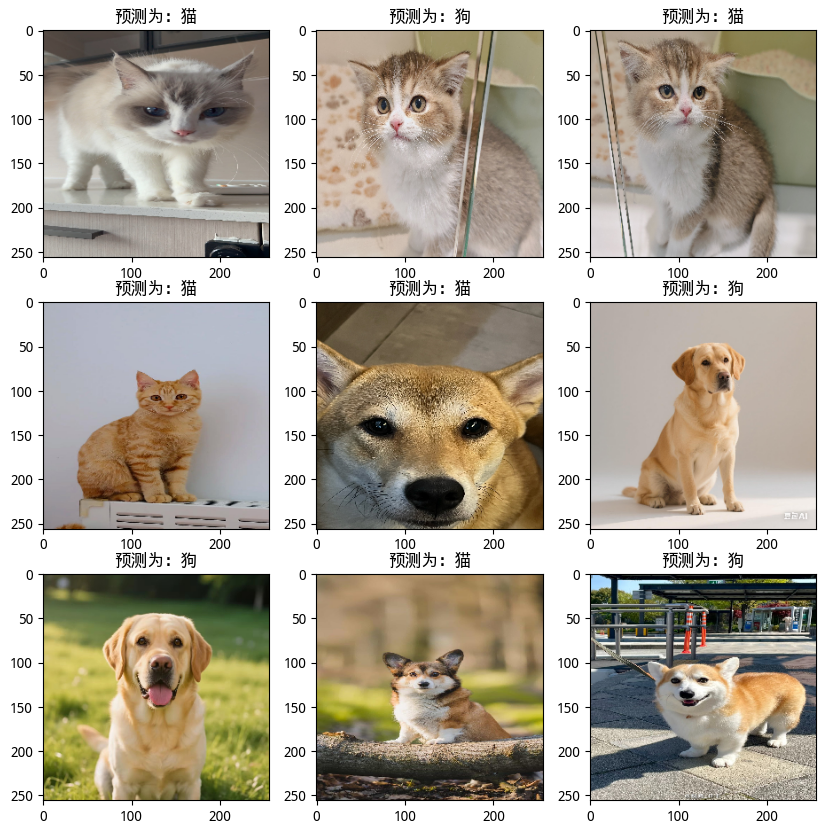

In [22]:
import matplotlib as mlp
font2={
    'family':'WenQuanYi Micro Hei',
    'weight':'normal',
    'size':20}
mlp.rcParams['font.family']='WenQuanYi Micro Hei'
mlp.rcParams['axes.unicode_minus']=False
from matplotlib import pyplot as plt
from matplotlib.image import imread
from tensorflow.keras.preprocessing.image import load_img,img_to_array
a=[i for i in range(1,10)]
fig=plt.figure(figsize=(10,10))
for i in a:
    img_name=str(i)+'.jpg'
    img_ori=load_img(img_name,target_size=(128,128))
    img=img_to_array(img_ori)
    img=img.astype('float32')/255
    img=img.reshape(1,128,128,3)
    result=(model.predict(img)>0.5).astype("int32")
    img_ori=load_img(img_name,target_size=(256,256))
    plt.subplot(3,3,i)
    plt.imshow(img_ori)
    plt.title('预测为：狗'if result[0][0]==1 else '预测为：猫')
plt.show()